# Introduction

## Model Comparison

This notebook compares the performance of all sentiment classification models developed in the project. The results from each model experiment are aggregated and evaluated in order to determine the most effective model for sentiment prediction.

The comparison includes the following models:

- Logistic Regression  
- Support Vector Machine (SVM)
- Naves Bayes
- BERT


The models are compared using key evaluation metrics including accuracy and F1-score, allowing the best performing model to be identified for the sentiment analysis task.

In [2]:
# Install Neccessary libraries
!pip install pandas matplotlib seaborn

In [14]:
# Import Neccessary libraries 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Model Results
Load the CSV files saved from each model notebook.

In [15]:
lr_results = pd.read_csv("models/logistic_regression_results.csv")

svm_results = pd.read_csv("models/svm_results.csv")

bert_results = pd.read_csv("models/bert_results.csv")

naive_bayes_results = pd.read_csv("models/naive_bayes_results.csv")



## Combine Results

In [16]:
all_results = pd.concat([lr_results, svm_results, bert_results, naive_bayes_results, ], ignore_index=True)

all_results

,Model,Features,Accuracy,F1 Score
0,Logistic Regression,TF-IDF,0.885835,0.895420
1,Logistic Regression,TF-IDF + Metadata,0.886403,0.895865
2,SVM,TF-IDF,0.885134,0.894730
3,SVM,TF-IDF + Metadata,0.885321,0.894885
4,BERT,Transformer,0.898791,0.938429
5,Naive Bayes,TF-IDF,0.910200,0.900400
6,Naive Bayes,TF-IDF + Metadata,0.884300,0.863300


## Best Model selection

In [17]:
best_model = all_results.loc[all_results["Accuracy"].idxmax()]

best_model

Model       Naive Bayes
Features         TF-IDF
Accuracy         0.9102
F1 Score         0.9004
Name: 5, dtype: object

In [22]:
all_results["Score"] = (all_results["Accuracy"] + all_results["F1 Score"]) / 2
best_model = all_results.loc[all_results["Score"].idxmax()]

best_model

Model              BERT
Features    Transformer
Accuracy       0.898791
F1 Score       0.938429
Score           0.91861
Name: 4, dtype: object

Although Naive Bayes achieved the highest accuracy, BERT outperformed all models in terms of F1-score, indicating a superior balance between precision and recall. This suggests that BERT is more effective at correctly identifying both positive and negative classes, making it the most robust model for this task

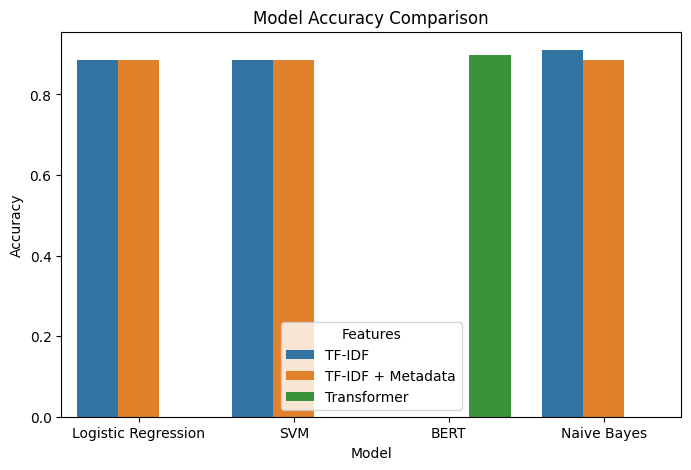

In [18]:
# accuracy comparison chart
plt.figure(figsize=(8,5))

sns.barplot(data=all_results, x="Model", y="Accuracy", hue="Features")

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")

plt.show()

Naive Bayes (TF-IDF) achieved the highest accuracy (0.91), making it the top-performing model based on accuracy alone.
- BERT (Transformer) also performed strongly (0.90), but slightly below Naive Bayes.

- Logistic Regression and SVM showed similar performance (0.89), indicating consistent but slightly lower accuracy.

- Adding metadata features did not significantly improve performance for most models.

## F1 Score Comparison
F1 is important because the dataset is imbalanced.

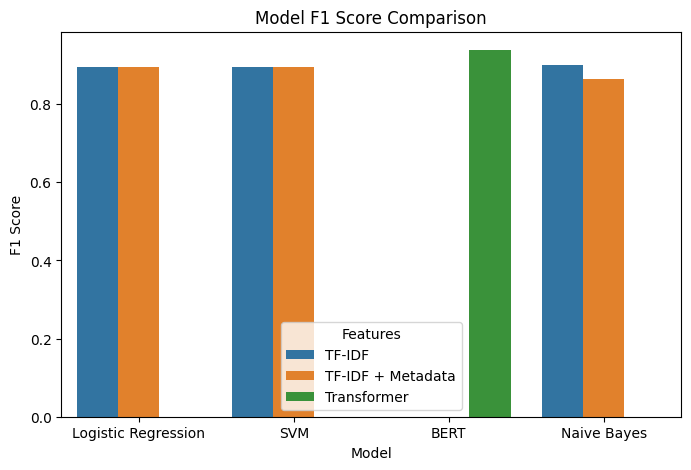

In [19]:
plt.figure(figsize=(8,5))

sns.barplot(data=all_results, x="Model", y="F1 Score", hue="Features")

plt.title("Model F1 Score Comparison")

plt.show()

BERT (Transformer) achieved the highest F1-score (0.94), indicating the best overall performance in correctly identifying both positive and negative classes.
- Naive Bayes (TF-IDF) performed well (0.90) but was lower than BERT, suggesting less balanced predictions.

- Logistic Regression and SVM showed similar performance (0.89), indicating consistent but moderate results.

- Adding metadata features did not significantly improve F1-scores and slightly reduced performance for some models.

# Save Final Comparison Table

In [20]:
all_results.to_csv("models/final_model_comparison.csv", index=False)